In [1]:
# Import dependencies
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import log_loss, accuracy_score
from tqdm import tqdm
import shap
import math
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# Start SHAP
shap.initjs()

In [3]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [4]:
# Create custom neural network for training
class SC_Net(nn.Module):
    def __init__(self, input_size, n_hidden1, n_hidden2, n_hidden3):
        super().__init__()

        '''
        Constructor for SC_Net
        '''
        self.hidden1 = nn.Linear(input_size, n_hidden1)
        self.hidden2 = nn.Linear(n_hidden1, n_hidden2)
        self.hidden3 = nn.Linear(n_hidden2, n_hidden3)
        self.out = nn.Linear(n_hidden3, 2)

    def forward(self, x):
        '''
        Predict method for SC_Net
        '''
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        x = self.out(x)
        return x

    def train_model(model,criterion,optimizer,trainloader,num_iter):
        '''
        Trains the SC_Net model

        Inputs:
            model(SC_Net): instance of the SC_Net
            criterion(nn.CrossEntropyLoss): loss function to use for training
            trainloader(torch.utils.data.DataLoader): DataLoader for training set
            num_iter(int): number of iterations/epochs of training

        Returns:
            model(SC_Net): trained model
        '''
        model.train() # Set the model to training mode

        # Initialize the list containing the total loss values for each epoch, across all minibatches
        cost = []

        # Perform training for the specified number of epochs
        for epoch in range(num_iter):
            # Initialize the current total loss
            current_total_loss = 0.0

            for i, data in enumerate(trainloader):
                # Get X and y for the minibatch
                inputs, labels = data[0], data[1]
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the gradients
                optimizer.zero_grad()

                # Calculate the predictions and the loss
                outputs = model.forward(inputs)
                loss = criterion(outputs, labels)

                # Perform backpropagation
                loss.backward()

                # Update the weights with the optimizer
                optimizer.step()

                # Update the current total loss
                current_total_loss += loss.item()

            # Update the list containing the total loss values for each epoch, across all minibatches
            cost.append(current_total_loss)

        # Return the trained model
        return model


    def test_model(model,test_loader):
        '''
        Tests the trained model on the test set

        Inputs:
            model(SC_Net): instance of the SC_Net
            test_loader(torch.utils.data.DataLoader): DataLoader for test set

        Returns:
            test_preds(list): list of predicted probabilities for the observations being cases where the petitioner wins
            test_preds_discrete(list): list of the discrete class predictions from the model encoded as integers
            y_true(list): list of the actual target values from the testloader encoded as integers
        '''

        with torch.no_grad():
            # Set the model to evaluation mode
            model.eval()

            # Initialize the list of test predictions
            test_preds = []

            # Initialize the list of actual target values from the testloader encoded as integers
            y_true = []

            # Get the predictions on the test set
            for test_data in test_loader:
                inputs, labels = test_data[0], test_data[1]
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model.forward(inputs)
                test_preds.extend(outputs.squeeze().tolist())
                y_true.extend(labels.tolist())

        # Convert test_preds to discrete class predictions
        test_preds_discrete = np.argmax(test_preds, axis=1)

        # Return the test predictions and the actual target values from the testloader encoded as integers
        return test_preds, test_preds_discrete, y_true

In [5]:
# Read the preprocessed data csv as a DataFrame
preprocess_data_df = pd.read_csv("preprocessed_case_data_a.csv")

# Preview the preprocessed data
preprocess_data_df.head()

,caseId,term,naturalCourt,petitioner,respondent,jurisdiction,threeJudgeFdc,caseOrigin,caseSource,lcDisagreement,lcDisposition,lcDispositionDirection,partyWinning,issue,issueArea,lawType,lawSupp
0,1946-001,1946,1301,198.0,172.0,6.0,0.0,51.0,29.0,0.0,2.0,1.0,1.0,80180.0,8.0,6.0,600.0
1,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
2,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
3,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0
4,1946-002,1946,1301,100.0,27.0,1.0,0.0,123.0,30.0,0.0,2.0,1.0,0.0,10500.0,1.0,6.0,600.0


In [6]:
"""
Create the following interaction terms:
1) Respondent x Issue
2) Petitioner x Issue
3) Respondent x Petitioner
4) caseSource x Issue
"""
preprocess_data_df["respondent_issue"] = str(preprocess_data_df["respondent"]) + ":" + str(preprocess_data_df["issue"])
preprocess_data_df["petitioner_issue"] = str(preprocess_data_df["petitioner"]) + ":" + str(preprocess_data_df["issue"])
preprocess_data_df["respondent_petitioner"] = str(preprocess_data_df["respondent"]) + ":" + str(preprocess_data_df["petitioner"])
preprocess_data_df["caseSource_issue"] = str(preprocess_data_df["caseSource"]) + ":" + str(preprocess_data_df["issue"])

In [7]:
"""
Split the preprocessed data into train and test splits based on the caseId to
prevent data leakage.
"""
group_shuffle_splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=0)

# Get the train and test indices.
train_indices, test_full_indices = next(group_shuffle_splitter.split(preprocess_data_df, groups=preprocess_data_df["caseId"]))

# Get the train and test splits.
train = preprocess_data_df.iloc[train_indices]
test_full = preprocess_data_df.iloc[test_full_indices]

# Split the full test split into validation and test splits.
group_shuffle_splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=0)
val_indices, test_indices = next(group_shuffle_splitter_test.split(test_full, groups=test_full["caseId"]))

# Get the val and test splits.
val = test_full.iloc[val_indices]
test = test_full.iloc[test_indices]

                            term  naturalCourt  petitioner  respondent  \
term                    1.000000      0.969210   -0.087133    0.043194   
naturalCourt            0.969210      1.000000   -0.090488    0.031886   
petitioner             -0.087133     -0.090488    1.000000    0.037377   
respondent              0.043194      0.031886    0.037377    1.000000   
jurisdiction           -0.092432     -0.093243   -0.026216   -0.007819   
threeJudgeFdc          -0.081053     -0.073068   -0.008345    0.080910   
caseOrigin             -0.100353     -0.087034   -0.091446   -0.333833   
caseSource             -0.148951     -0.134799   -0.037270   -0.286652   
lcDisagreement          0.099642      0.100167   -0.038526    0.022831   
lcDisposition           0.096823      0.095073    0.069086   -0.019316   
lcDispositionDirection  0.172217      0.165583   -0.097969    0.237642   
partyWinning            0.058960      0.050138    0.032267    0.021906   
issue                  -0.071382     -

<Axes: >

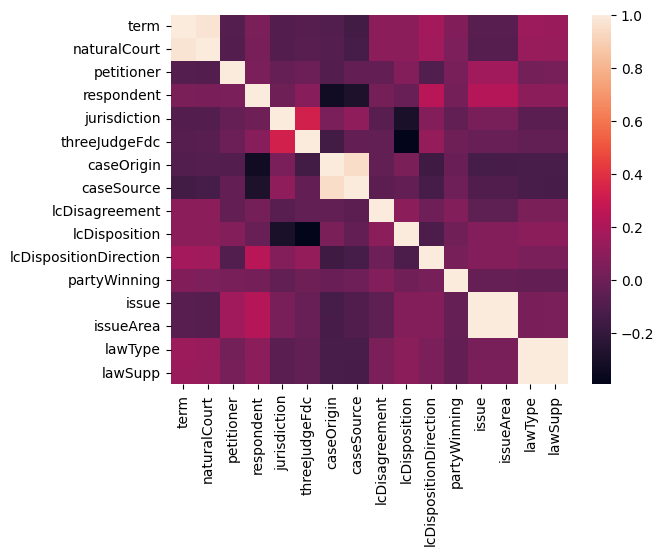

In [8]:
# Display the correlation matrix of the current dataset to spot possibly redundant features.
correlation_matrix = train.drop(columns=["caseId", "respondent_issue", "petitioner_issue", "respondent_petitioner", "caseSource_issue"]).corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix)

In [9]:
# Print a mutual information matrix for the features in relation to the target variable (partyWinning)
mutual_info_matrix = mutual_info_classif(train.drop(columns=["caseId", "partyWinning", "respondent_issue", "petitioner_issue", "respondent_petitioner", "caseSource_issue"]), train["partyWinning"], random_state=0)

# Print the mutual information matrix (found from research that it assesses any kind of relationship - linear or nonlinear).
print("Mutual Information Matrix")
print(mutual_info_matrix)

Mutual Information Matrix
[0.02029102 0.01839434 0.03777114 0.03804108 0.         0.
 0.01257193 0.01323646 0.00558989 0.00385725 0.00105355 0.03752972
 0.0057246  0.         0.02216113]


In [10]:
"""
The following pairs of features were found to be highly correlated with each other:
1) Term and Natural Court
2) Case Origin and Case Source
3) Issue and Issue Area
4) Law Type and Law Supp
"""

"""
Select the features from each pair to remove based on the mutual information matrix
values (if a feature has a higher value in the mutual information matrix than another,
discard the feature with the lower value).
"""

highly_correlated_features_to_remove = ["naturalCourt", "caseOrigin", "issueArea", "lawType"]

# Remove these features from all splits
train.drop(columns=highly_correlated_features_to_remove, inplace=True)
val.drop(columns=highly_correlated_features_to_remove, inplace=True)
test.drop(columns=highly_correlated_features_to_remove, inplace=True)

/tmp/ipykernel_14835/3977528824.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(columns=highly_correlated_features_to_remove, inplace=True)
/tmp/ipykernel_14835/3977528824.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val.drop(columns=highly_correlated_features_to_remove, inplace=True)
/tmp/ipykernel_14835/3977528824.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns=highly_correlated_features

In [11]:
# Further split these train and test splits into X and y.
X_train = train.drop(columns=["partyWinning", "caseId"])
y_train = train["partyWinning"]
X_val = val.drop(columns=["partyWinning", "caseId"])
y_val = val["partyWinning"]
X_test = test.drop(columns=["partyWinning", "caseId"])
y_test = test["partyWinning"]

X_train.head()

,term,petitioner,respondent,jurisdiction,threeJudgeFdc,caseSource,lcDisagreement,lcDisposition,lcDispositionDirection,issue,lawSupp,respondent_issue,petitioner_issue,respondent_petitioner,caseSource_issue
0,1946,198.0,172.0,6.0,0.0,29.0,0.0,2.0,1.0,80180.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
1,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
2,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
3,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...
4,1946,100.0,27.0,1.0,0.0,30.0,0.0,2.0,1.0,10500.0,600.0,0 172.0\n1 27.0\n2 27.0...,0 198.0\n1 100.0\n2 100.0...,0 172.0\n1 27.0\n2 27.0...,0 29.0\n1 30.0\n2 30.0\n3...


In [12]:
def prep_dataloader(X, y, is_train, batch_size):
    '''
    Creates DataLoader using the dataset

    Inputs:
        X(np.array): data inputs
        y(np.array): data labels
        batch_size(int): batch size

    Returns:
        loader(torch.utils.data.DataLoader): DataLoader for dataset
    '''
    # Create the dataset
    dataset = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())

    # Create the DataLoader for the dataset
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=is_train)

    # Return the DataLoader
    return loader

In [30]:
# Initialize the features for ordinal encoding.
features_for_ordinal_encoding = ["respondent_issue", "petitioner_issue", "respondent_petitioner",
                                 "caseSource_issue"]

# Perform hyperparameter tuning
learning_rates = [1e-4, 5e-3, 1e-3, 5e-2, 1e-2]
nums_epochs = [20, 50, 100]
batch_sizes = [16, 32, 64, 128]

best_crossval_log_loss = float("inf")
best_learning_rate = learning_rates[0]
best_num_epochs = nums_epochs[0]
best_batch_size = batch_sizes[0]

# Transform the interaction terms using ordinal encoding for the training data.
ord_enc = OrdinalEncoder()
enc_interaction_terms_train = pd.DataFrame(data=ord_enc.fit_transform(X_train[features_for_ordinal_encoding]),
                                            columns=features_for_ordinal_encoding,
                                            index=X_train.index)
non_enc_columns_train = X_train.drop(columns=features_for_ordinal_encoding)
X_train_transformed = pd.concat([non_enc_columns_train, enc_interaction_terms_train], axis=1).to_numpy()
#y_train = y_train

# Transform the validation data.
enc_interaction_terms_val = pd.DataFrame(data=ord_enc.transform(X_val[features_for_ordinal_encoding]),
                                        columns=features_for_ordinal_encoding,
                                        index=X_val.index)
non_enc_columns_val = X_val.drop(columns=features_for_ordinal_encoding)
X_val_transformed = pd.concat([non_enc_columns_val, enc_interaction_terms_val], axis=1).to_numpy()
#y_val = y_val.to_numpy()

for learning_rate in tqdm(learning_rates, desc="Using learning_rate"):
    for num_epoch in tqdm(nums_epochs, desc="Using num_epoch"):
        for batch_size in tqdm(batch_sizes, desc="Using batch_size"):
            # Instantiate a model setting the parameters as appropriate.
            model = SC_Net(input_size=15, n_hidden1=128, n_hidden2=64, n_hidden3=32).to(device)

            # Prepare a DataLoader for the training data.
            trainloader = prep_dataloader(X_train_transformed, y_train, is_train=True, batch_size=batch_size)

            # Train the model on the transformed training data.
            model = model.train_model(nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=learning_rate), trainloader, num_epoch)

            # Prepare a DataLoader for the validation data.
            valloader = prep_dataloader(X_val_transformed, y_val, is_train=False, batch_size=batch_size)

            val_preds, val_preds_discrete, y_true = model.test_model(valloader)
            m = nn.Softmax(dim=1)
            input = torch.tensor(val_preds)
            output = m(input)
            current_log_loss = log_loss(y_val, output)

            """
            Update the best validation log loss and the parameters corresponding
            to this log loss.
            """
            if best_crossval_log_loss > current_log_loss:
                best_crossval_log_loss = current_log_loss
                best_learning_rate = learning_rate
                best_num_epoch = num_epoch
                best_batch_size = batch_size

            tqdm.write(f"Best validation log loss: {best_crossval_log_loss:.4f} | Params: lr={best_learning_rate}, num_epoch={best_num_epoch}, batch_size={best_batch_size}")

Using num_epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [00:24<?, ?it/s]

Using batch_size:  25%|██▌       | 1/4 [00:24<01:12, 24.33s/it]

Best validation log loss: 3.6411 | Params: lr=0.0001, num_epoch=20, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [00:35<?, ?it/s]

Using batch_size:  50%|█████     | 2/4 [00:35<00:33, 16.76s/it]

Best validation log loss: 1.0687 | Params: lr=0.0001, num_epoch=20, batch_size=32


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [00:42<?, ?it/s]

Using batch_size:  75%|███████▌  | 3/4 [00:42<00:12, 12.06s/it]

Best validation log loss: 1.0687 | Params: lr=0.0001, num_epoch=20, batch_size=32


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [00:45<?, ?it/s]

Using batch_size: 100%|██████████| 4/4 [00:45<00:00, 11.44s/it]

Using num_epoch:  33%|███▎      | 1/3 [00:45<01:31, 45.75s/it]

Best validation log loss: 1.0687 | Params: lr=0.0001, num_epoch=20, batch_size=32




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [01:40<?, ?it/s]

Using batch_size:  25%|██▌       | 1/4 [00:54<02:42, 54.26s/it]

Best validation log loss: 0.6708 | Params: lr=0.0001, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [02:08<?, ?it/s]

Using batch_size:  50%|█████     | 2/4 [01:22<01:18, 39.11s/it]

Best validation log loss: 0.6708 | Params: lr=0.0001, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [02:24<?, ?it/s]

Using batch_size:  75%|███████▌  | 3/4 [01:38<00:28, 28.37s/it]

Best validation log loss: 0.6708 | Params: lr=0.0001, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [02:32<?, ?it/s]

Using batch_size: 100%|██████████| 4/4 [01:47<00:00, 26.81s/it]

Using num_epoch:  67%|██████▋   | 2/3 [02:32<01:21, 81.92s/it]

Best validation log loss: 0.6708 | Params: lr=0.0001, num_epoch=50, batch_size=16




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [04:19<?, ?it/s]

Using batch_size:  25%|██▌       | 1/4 [01:46<05:19, 106.66s/it]

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [05:16<?, ?it/s]

Using batch_size:  50%|█████     | 2/4 [02:43<02:34, 77.12s/it] 

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [05:46<?, ?it/s]

Using batch_size:  75%|███████▌  | 3/4 [03:13<00:55, 55.91s/it]

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:   0%|          | 0/5 [06:05<?, ?it/s]

Using batch_size: 100%|██████████| 4/4 [03:32<00:00, 53.00s/it]

Using learning_rate:  20%|██        | 1/5 [06:05<24:20, 365.02s/it]

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16



Using num_epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]




Using learning_rate:  20%|██        | 1/5 [06:25<24:20, 365.02s/it]

Using batch_size:  25%|██▌       | 1/4 [00:20<01:02, 20.82s/it]

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [06:37<24:20, 365.02s/it]

Using batch_size:  50%|█████     | 2/4 [00:32<00:30, 15.21s/it]

Best validation log loss: 0.6461 | Params: lr=0.0001, num_epoch=100, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [06:43<24:20, 365.02s/it]

Using batch_size:  75%|███████▌  | 3/4 [00:38<00:11, 11.24s/it]

Best validation log loss: 0.6459 | Params: lr=0.005, num_epoch=20, batch_size=64







Using learning_rate:  20%|██        | 1/5 [06:47<24:20, 365.02s/it]

Using batch_size: 100%|██████████| 4/4 [00:42<00:00, 10.51s/it]

Using num_epoch:  33%|███▎      | 1/3 [00:42<01:24, 42.05s/it]

Best validation log loss: 0.6459 | Params: lr=0.005, num_epoch=20, batch_size=64




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [07:40<24:20, 365.02s/it]

Using batch_size:  25%|██▌       | 1/4 [00:53<02:39, 53.07s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [08:09<24:20, 365.02s/it]

Using batch_size:  50%|█████     | 2/4 [01:21<01:17, 38.85s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [08:24<24:20, 365.02s/it]

Using batch_size:  75%|███████▌  | 3/4 [01:37<00:28, 28.18s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [08:33<24:20, 365.02s/it]

Using batch_size: 100%|██████████| 4/4 [01:46<00:00, 26.67s/it]

Using num_epoch:  67%|██████▋   | 2/3 [02:28<01:20, 80.06s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [10:22<24:20, 365.02s/it]

Using batch_size:  25%|██▌       | 1/4 [01:48<05:25, 108.40s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16







Using learning_rate:  20%|██        | 1/5 [11:18<24:20, 365.02s/it]

Using batch_size:  50%|█████     | 2/4 [02:45<02:36, 78.01s/it] 

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [11:50<24:20, 365.02s/it]

Using batch_size:  75%|███████▌  | 3/4 [03:16<00:56, 56.68s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  20%|██        | 1/5 [12:08<24:20, 365.02s/it]

Using batch_size: 100%|██████████| 4/4 [03:34<00:00, 53.61s/it]

Using learning_rate:  40%|████      | 2/5 [12:08<18:11, 363.93s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16



Using num_epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [12:29<18:11, 363.93s/it]

Using batch_size:  25%|██▌       | 1/4 [00:21<01:04, 21.49s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [12:41<18:11, 363.93s/it]

Using batch_size:  50%|█████     | 2/4 [00:32<00:31, 15.58s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [12:47<18:11, 363.93s/it]

Using batch_size:  75%|███████▌  | 3/4 [00:38<00:11, 11.23s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [12:50<18:11, 363.93s/it]

Using batch_size: 100%|██████████| 4/4 [00:42<00:00, 10.68s/it]

Using num_epoch:  33%|███▎      | 1/3 [00:42<01:25, 42.74s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [13:44<18:11, 363.93s/it]

Using batch_size:  25%|██▌       | 1/4 [00:53<02:40, 53.62s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [14:12<18:11, 363.93s/it]

Using batch_size:  50%|█████     | 2/4 [01:21<01:17, 38.63s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [14:28<18:11, 363.93s/it]

Using batch_size:  75%|███████▌  | 3/4 [01:37<00:28, 28.01s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [14:37<18:11, 363.93s/it]

Using batch_size: 100%|██████████| 4/4 [01:46<00:00, 26.56s/it]

Using num_epoch:  67%|██████▋   | 2/3 [02:28<01:20, 80.09s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [16:23<18:11, 363.93s/it]

Using batch_size:  25%|██▌       | 1/4 [01:46<05:19, 106.49s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16







Using learning_rate:  40%|████      | 2/5 [17:19<18:11, 363.93s/it]

Using batch_size:  50%|█████     | 2/4 [02:42<02:33, 76.91s/it] 

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [17:51<18:11, 363.93s/it]

Using batch_size:  75%|███████▌  | 3/4 [03:13<00:56, 56.06s/it]

Best validation log loss: 0.6452 | Params: lr=0.005, num_epoch=50, batch_size=16


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  40%|████      | 2/5 [18:08<18:11, 363.93s/it]

Using batch_size: 100%|██████████| 4/4 [03:31<00:00, 52.89s/it]

Using learning_rate:  60%|██████    | 3/5 [18:08<12:04, 362.39s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128



Using num_epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [18:30<12:04, 362.39s/it]

Using batch_size:  25%|██▌       | 1/4 [00:21<01:04, 21.50s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [18:41<12:04, 362.39s/it]

Using batch_size:  50%|█████     | 2/4 [00:32<00:31, 15.59s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [18:47<12:04, 362.39s/it]

Using batch_size:  75%|███████▌  | 3/4 [00:39<00:11, 11.31s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [18:51<12:04, 362.39s/it]

Using batch_size: 100%|██████████| 4/4 [00:43<00:00, 10.75s/it]

Using num_epoch:  33%|███▎      | 1/3 [00:43<01:26, 43.01s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]




Using learning_rate:  60%|██████    | 3/5 [19:44<12:04, 362.39s/it]

Using batch_size:  25%|██▌       | 1/4 [00:53<02:39, 53.18s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128







Using learning_rate:  60%|██████    | 3/5 [20:13<12:04, 362.39s/it]

Using batch_size:  50%|█████     | 2/4 [01:21<01:16, 38.42s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [20:28<12:04, 362.39s/it]

Using batch_size:  75%|███████▌  | 3/4 [01:37<00:28, 28.16s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [20:37<12:04, 362.39s/it]

Using batch_size: 100%|██████████| 4/4 [01:45<00:00, 26.45s/it]

Using num_epoch:  67%|██████▋   | 2/3 [02:28<01:19, 79.96s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]




Using learning_rate:  60%|██████    | 3/5 [22:24<12:04, 362.39s/it]

Using batch_size:  25%|██▌       | 1/4 [01:46<05:19, 106.41s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [23:21<12:04, 362.39s/it]

Using batch_size:  50%|█████     | 2/4 [02:44<02:35, 77.74s/it] 

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [23:52<12:04, 362.39s/it]

Using batch_size:  75%|███████▌  | 3/4 [03:15<00:56, 56.50s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  60%|██████    | 3/5 [24:11<12:04, 362.39s/it]

Using batch_size: 100%|██████████| 4/4 [03:33<00:00, 53.41s/it]

Using learning_rate:  80%|████████  | 4/5 [24:11<06:02, 362.43s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128



Using num_epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [24:32<06:02, 362.43s/it]

Using batch_size:  25%|██▌       | 1/4 [00:21<01:03, 21.22s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [24:43<06:02, 362.43s/it]

Using batch_size:  50%|█████     | 2/4 [00:32<00:30, 15.30s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [24:50<06:02, 362.43s/it]

Using batch_size:  75%|███████▌  | 3/4 [00:38<00:11, 11.29s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [24:53<06:02, 362.43s/it]

Using batch_size: 100%|██████████| 4/4 [00:42<00:00, 10.60s/it]

Using num_epoch:  33%|███▎      | 1/3 [00:42<01:24, 42.42s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [25:47<06:02, 362.43s/it]

Using batch_size:  25%|██▌       | 1/4 [00:53<02:40, 53.60s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128







Using learning_rate:  80%|████████  | 4/5 [26:15<06:02, 362.43s/it]

Using batch_size:  50%|█████     | 2/4 [01:21<01:17, 38.52s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [26:30<06:02, 362.43s/it]

Using batch_size:  75%|███████▌  | 3/4 [01:36<00:27, 27.94s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [26:39<06:02, 362.43s/it]

Using batch_size: 100%|██████████| 4/4 [01:46<00:00, 26.53s/it]

Using num_epoch:  67%|██████▋   | 2/3 [02:28<01:19, 79.88s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128




Using batch_size:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [28:26<06:02, 362.43s/it]

Using batch_size:  25%|██▌       | 1/4 [01:46<05:19, 106.55s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [29:23<06:02, 362.43s/it]

Using batch_size:  50%|█████     | 2/4 [02:43<02:34, 77.31s/it] 

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [29:54<06:02, 362.43s/it]

Using batch_size:  75%|███████▌  | 3/4 [03:14<00:56, 56.29s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(





Using learning_rate:  80%|████████  | 4/5 [30:12<06:02, 362.43s/it]

Using batch_size: 100%|██████████| 4/4 [03:32<00:00, 53.12s/it]

Using learning_rate: 100%|██████████| 5/5 [30:12<00:00, 362.45s/it]

Best validation log loss: 0.6419 | Params: lr=0.001, num_epoch=100, batch_size=128


In [31]:
print("Best log_loss:", best_crossval_log_loss)
print("Best learning_rate:", best_learning_rate)
print("Best num_epoch:", best_num_epoch)
print("Best batch_size:", best_batch_size)

Best log_loss: 0.6418731459671912
Best learning_rate: 0.001
Best num_epoch: 100
Best batch_size: 128


In [34]:
# Instantiate a model setting the parameters as appropriate.
model = SC_Net(input_size=15, n_hidden1=128, n_hidden2=64, n_hidden3=32).to(device)

# Transform the interaction terms using ordinal encoding.
ord_enc = OrdinalEncoder()
enc_interaction_terms_train = pd.DataFrame(data=ord_enc.fit_transform(X_train[features_for_ordinal_encoding]),
                                            columns=features_for_ordinal_encoding,
                                            index=X_train.index)
non_enc_columns_train = X_train.drop(columns=features_for_ordinal_encoding)
X_train_transformed = pd.concat([non_enc_columns_train, enc_interaction_terms_train], axis=1).to_numpy()

# Prepare a DataLoader for the training data.
trainloader = prep_dataloader(X_train_transformed, y_train, is_train=True, batch_size=best_batch_size)

# Train the model on the transformed training data.
model = model.train_model(nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=best_learning_rate), trainloader, num_iter=best_num_epoch)

# Transform the validation data.
enc_interaction_terms_val = pd.DataFrame(data=ord_enc.transform(X_val[features_for_ordinal_encoding]),
                                        columns=features_for_ordinal_encoding,
                                        index=X_val.index)
non_enc_columns_val = X_val.drop(columns=features_for_ordinal_encoding)
X_val_transformed = pd.concat([non_enc_columns_val, enc_interaction_terms_val], axis=1).to_numpy()

In [41]:
# Prepare a DataLoader for the validation data.
valloader = prep_dataloader(X_val_transformed, y_val, is_train=False, batch_size=best_batch_size)

# Make predictions for the validation set.
val_preds, val_predictions, y_true = model.test_model(valloader)

In [46]:
# Transform the test data.
enc_interaction_terms_test = pd.DataFrame(data=ord_enc.transform(X_test[features_for_ordinal_encoding]),
                                                 columns=features_for_ordinal_encoding,
                                                 index=X_test.index)
non_enc_columns_test = X_test.drop(columns=features_for_ordinal_encoding)
X_test_transformed = pd.concat([non_enc_columns_test, enc_interaction_terms_test], axis=1).to_numpy()

# Prepare a DataLoader for the test data.
testloader = prep_dataloader(X_test_transformed, y_test, is_train=False, batch_size=best_batch_size)

# Make predictions for the test set.
test_preds, test_preds_discrete, y_true = model.test_model(testloader)

# Perform model evaluation.
test_log_loss = log_loss(y_test, test_preds)
test_accuracy = accuracy_score(y_test, test_preds_discrete)
print("Test Log Loss:", test_log_loss)
print("Test Accuracy:", test_accuracy)

Test Log Loss: 2.2204460492503136e-16
Test Accuracy: 0.5050352467270897


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
